<a href="https://colab.research.google.com/github/fluorescentlightpower/mifi_homework/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%94%D0%B0%D0%BD%D0%BD%D1%8B%D0%B5_%D1%84%D0%B8%D0%B7%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B9_%D0%B0%D0%BA%D1%82%D0%B8%D0%B2%D0%BD%D0%BE%D1%81%D1%82%D0%B8%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import re
import gdown
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.signal import butter, filtfilt
from sklearn.cluster import KMeans, DBSCAN
import hdbscan

np.random.seed(42)

In [2]:
import zipfile
url = 'https://drive.google.com/uc?id=1_F5uWm_Q83TnaT0sHxDB_eXpXH_XjCrq'
gdown.download(url, 'data.zip', quiet=False)

# Unzip the downloaded file
with zipfile.ZipFile('data.zip', 'r') as zip_ref:
    zip_ref.extractall('.')


Downloading...
From (original): https://drive.google.com/uc?id=1_F5uWm_Q83TnaT0sHxDB_eXpXH_XjCrq
From (redirected): https://drive.google.com/uc?id=1_F5uWm_Q83TnaT0sHxDB_eXpXH_XjCrq&confirm=t&uuid=4f61334c-c022-4942-a528-ffcc1dacb7c9
To: /content/data.zip
100%|██████████| 108M/108M [00:00<00:00, 163MB/s]


In [72]:
df_raw = pd.read_csv('Physical_Activity_Monitoring_unlabeled.csv')
df = df_raw.copy()

In [73]:
df.iloc[0:30,0:20]

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,handGyro3,handMagne1,handMagne2,handMagne3,handOrientation1,handOrientation2,handOrientation3,handOrientation4,chestTemperature,chestAcc16_1
0,252.75,34.8750,0.902847,7.458720,6.032490,1.006100,7.445750,6.303650,-0.021952,0.004114,-0.000752,-9.995380,7.229100,-32.13990,0.561813,-0.218644,0.359836,0.712095,36.6250,-0.106754
1,3652.45,29.7500,-4.069330,3.761680,8.279720,-5.972500,3.222730,6.908970,0.116054,-0.375968,-0.012890,40.455800,-1.196920,-37.55520,0.884964,-0.281047,-0.145657,0.341518,34.6875,0.069756
2,504.76,34.3750,-2.007540,-9.601800,0.773674,-1.803500,-9.589370,1.073680,0.020131,0.042189,-0.011507,7.267410,24.437900,-14.30050,0.535655,0.564385,0.371967,-0.506146,37.6250,0.326521
3,2801.61,31.9375,-13.262200,5.854430,0.899334,-13.611500,5.915110,0.840377,1.715630,-0.050492,-1.829000,46.482200,-7.839160,-13.62420,0.648205,0.540984,-0.282560,-0.455332,36.5000,2.127460
4,441.01,33.5000,-0.013940,8.665400,4.398210,0.144153,8.568160,4.822200,-0.006938,-0.007383,-0.032679,3.977640,-22.423200,-20.17750,0.769041,-0.442364,0.232331,0.398638,35.8125,0.648395
5,2407.75,32.2500,-11.248600,4.705490,1.472190,-10.437400,4.458190,1.595360,1.376280,1.629110,-2.771060,35.452300,-33.659300,-20.96050,0.199763,0.512604,-0.394729,-0.735881,36.6250,0.672162
6,288.18,33.8125,-9.003480,3.480250,2.202730,-8.781060,3.450250,2.426420,0.291490,-0.142762,-0.277982,46.053400,-0.513600,2.54593,0.755744,-0.325815,-0.516071,0.237417,37.1875,0.554952
7,2926.96,31.8125,-1.183270,4.291570,6.435280,-1.338840,5.228640,7.488770,-0.100648,0.209315,0.150239,-13.532900,-30.558700,-57.85300,1.000000,0.000000,0.000000,0.000000,36.4375,1.031350
8,738.33,34.5625,-8.875780,-5.294850,1.156600,-8.606980,-5.447070,1.569890,-0.276623,-0.353238,0.840874,43.116500,5.022990,-19.63580,0.386860,0.668416,-0.096557,-0.627882,37.5625,-0.779648
9,2934.54,31.7500,-6.033980,6.362040,8.818830,-2.939410,6.993440,8.966410,0.124129,-0.301420,-0.013721,53.651000,-8.965910,-51.44600,1.000000,0.000000,0.000000,0.000000,36.3750,0.548167


In [74]:
df.iloc[0:30,20:40]

,chestAcc16_2,chestAcc16_3,chestAcc6_1,chestAcc6_2,chestAcc6_3,chestGyro1,chestGyro2,chestGyro3,chestMagne1,chestMagne2,chestMagne3,chestOrientation1,chestOrientation2,chestOrientation3,chestOrientation4,ankleTemperature,ankleAcc16_1,ankleAcc16_2,ankleAcc16_3,ankleAcc6_1
0,1.66721,9.327970,-0.292054,1.56048,9.749260,-0.019807,-0.034096,0.003963,39.546600,5.58050,-27.966000,0.987675,-0.081231,-0.009229,0.133472,34.1250,-0.458486,-9.074420,-4.479550,-0.318531
1,2.61466,-11.891000,-0.139514,2.40386,-10.968600,0.299329,0.272314,0.249314,17.429500,2.61508,39.329800,0.155581,-0.908072,-0.388069,-0.024528,33.6250,6.035340,2.787170,-2.055420,6.397190
2,9.81131,0.016322,0.261230,9.78271,0.460448,0.009436,-0.015007,-0.037835,5.635200,-25.82200,-3.770940,0.721119,-0.680477,0.090302,0.093721,33.9375,9.238750,2.809250,-2.562960,9.142330
3,8.91873,-8.582920,2.372620,9.73020,-8.650230,0.078109,-0.099471,0.488145,-1.194660,-38.68970,5.282490,0.367155,-0.663333,0.553109,0.345336,34.5625,13.540000,3.082240,2.573280,18.086300
4,9.73894,0.603203,0.519639,9.79662,0.897193,0.003127,-0.015282,-0.061410,4.600370,-25.65500,-3.638080,0.735751,-0.666812,0.086031,0.081430,34.6875,9.551770,-0.494227,-2.770790,9.545500
5,10.21600,-1.217800,-0.353022,9.33357,-1.169310,0.477854,-0.374119,-0.030835,-5.336100,-39.85210,-12.509900,0.347980,-0.393050,0.601259,0.602419,34.9375,2.863470,-2.595140,-0.742501,3.843900
6,9.41673,-2.533840,0.439262,9.43874,-2.110770,0.002726,-0.119148,-0.003113,-0.836677,-27.75450,30.063400,0.429579,-0.571943,-0.540254,-0.443248,34.6250,9.645970,-1.222850,-1.954920,9.685130
7,5.20757,-6.654670,0.779120,5.30829,-6.311000,0.359139,0.324683,-0.606432,1.574770,-57.68910,32.143400,1.000000,0.000000,0.000000,0.000000,33.8750,12.438300,4.190720,-2.152830,9.689590
8,9.92747,-0.042816,-0.911330,9.87589,0.482908,-0.115359,0.358244,0.219306,-2.904430,-37.76470,2.018630,0.222424,-0.153240,-0.673878,-0.687701,34.2500,9.151990,-0.104140,-3.742050,9.241350
9,8.12085,-10.390100,0.206102,8.95270,-10.422700,1.521560,-0.238826,-0.216137,19.977100,-10.11830,66.073200,1.000000,0.000000,0.000000,0.000000,33.8750,14.998300,3.257570,-1.426170,19.328800


In [75]:
df.iloc[0:30,40:53]

,ankleAcc6_2,ankleAcc6_3,ankleGyro1,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,-8.899070,-4.138470,0.043954,-0.025606,0.030239,-14.54470,27.33360,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,4.930160,-1.312670,-0.319186,-0.670163,1.786200,-32.82570,-15.77190,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,2.918150,-2.122940,0.065654,-0.009741,-0.006579,-18.81710,16.30890,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,1.822210,2.918510,2.970010,-0.163470,-3.495570,-26.74180,34.35660,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,-0.394571,-2.477670,0.013953,-0.028172,-0.003737,-17.77980,-3.99810,10.99500,0.171133,-0.748343,0.252988,-0.588807,6
5,-1.376860,-0.749085,-2.166630,0.395789,-0.734158,-37.23000,-17.66060,25.97660,0.081638,-0.564666,-0.465628,-0.676519,6
6,-1.225040,-1.355740,-0.022248,0.009919,0.016218,-61.35760,-33.90920,-13.77570,0.542814,-0.366369,0.626705,-0.422336,2
7,4.477920,-0.677887,0.051127,0.057945,0.394188,-63.83370,14.46170,14.48690,1.000000,0.000000,0.000000,0.000000,1
8,-0.153751,-3.384950,0.113362,0.016960,-0.009354,-37.21160,-2.25659,10.92460,0.146531,-0.810946,0.130713,-0.551189,8
9,6.716860,-2.083320,-0.117164,0.179439,-1.369650,-60.55190,-36.30930,-1.18247,1.000000,0.000000,0.000000,0.000000,1


In [76]:
df.iloc[0:30,40:54]

,ankleAcc6_2,ankleAcc6_3,ankleGyro1,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,-8.899070,-4.138470,0.043954,-0.025606,0.030239,-14.54470,27.33360,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,4.930160,-1.312670,-0.319186,-0.670163,1.786200,-32.82570,-15.77190,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,2.918150,-2.122940,0.065654,-0.009741,-0.006579,-18.81710,16.30890,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,1.822210,2.918510,2.970010,-0.163470,-3.495570,-26.74180,34.35660,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,-0.394571,-2.477670,0.013953,-0.028172,-0.003737,-17.77980,-3.99810,10.99500,0.171133,-0.748343,0.252988,-0.588807,6
5,-1.376860,-0.749085,-2.166630,0.395789,-0.734158,-37.23000,-17.66060,25.97660,0.081638,-0.564666,-0.465628,-0.676519,6
6,-1.225040,-1.355740,-0.022248,0.009919,0.016218,-61.35760,-33.90920,-13.77570,0.542814,-0.366369,0.626705,-0.422336,2
7,4.477920,-0.677887,0.051127,0.057945,0.394188,-63.83370,14.46170,14.48690,1.000000,0.000000,0.000000,0.000000,1
8,-0.153751,-3.384950,0.113362,0.016960,-0.009354,-37.21160,-2.25659,10.92460,0.146531,-0.810946,0.130713,-0.551189,8
9,6.716860,-2.083320,-0.117164,0.179439,-1.369650,-60.55190,-36.30930,-1.18247,1.000000,0.000000,0.000000,0.000000,1


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1        530560 non-null  float64
 3   handAcc16_2        530560 non-null  float64
 4   handAcc16_3        530560 non-null  float64
 5   handAcc6_1         530560 non-null  float64
 6   handAcc6_2         530560 non-null  float64
 7   handAcc6_3         530560 non-null  float64
 8   handGyro1          530560 non-null  float64
 9   handGyro2          530560 non-null  float64
 10  handGyro3          530560 non-null  float64
 11  handMagne1         530560 non-null  float64
 12  handMagne2         530560 non-null  float64
 13  handMagne3         530560 non-null  float64
 14  handOrientation1   530560 non-null  float64
 15  handOrientation2   530560 non-null  float64
 16  ha

Все данные импортировались в числовые типы. Есть пропуски, которые нужно будет обработать. Есть данные по температуре, ускорениям, скоростям, магнитному полю и ориентации для трех датчиков

In [78]:
df.describe()

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
count,534601.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,...,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,534601.000000
mean,1593.538159,32.451221,-4.435286,3.241949,4.079375,-4.375896,3.218250,4.262513,-0.008852,0.028801,...,-0.031911,0.002304,-28.756284,2.115624,14.723345,0.360159,-0.091093,0.303517,-0.173845,4.558615
std,1243.906483,1.754847,7.062004,7.224031,3.831257,7.068961,6.864782,3.822053,1.160112,0.926832,...,0.618840,2.036102,19.303887,22.253170,17.907491,0.301254,0.559400,0.344271,0.466304,2.318076
min,37.660000,27.500000,-114.755000,-82.550900,-73.949700,-61.214700,-61.824200,-61.577100,-19.690500,-7.609010,...,-7.701040,-14.019600,-172.865000,-136.951000,-102.716000,0.000003,-0.954848,-0.876838,-0.997040,1.000000
25%,475.500000,31.312500,-9.076360,0.682775,1.588777,-8.981072,0.687587,1.780160,-0.153182,-0.083315,...,-0.049003,-0.221911,-39.689950,-10.960850,2.252230,0.145023,-0.676392,0.006839,-0.580040,2.000000
50%,827.610000,32.875000,-5.465610,3.089205,4.157125,-5.434845,3.127145,4.413625,-0.004439,0.004013,...,-0.004481,0.000354,-26.285600,-0.014372,16.599500,0.240996,0.000000,0.322698,-0.281681,5.000000
75%,2876.990000,33.812500,0.383679,5.559742,6.864212,0.424770,5.592180,7.148178,0.130310,0.094342,...,0.048972,0.032649,-14.549500,19.245900,25.947100,0.501671,0.410052,0.594198,0.252247,7.000000
max,4007.730000,35.250000,60.912600,155.532000,78.480100,34.159400,62.259800,60.843700,22.960000,11.862600,...,6.002540,14.482700,41.764800,92.867000,122.521000,1.000000,0.959538,0.920506,0.996105,8.000000


In [79]:
df.nunique()

,0
timestamp,215964
handTemperature,125
handAcc16_1,333029
handAcc16_2,368754
handAcc16_3,359286
handAcc6_1,355762
handAcc6_2,392738
handAcc6_3,369648
handGyro1,484555
handGyro2,471432


Представлены данные от 8 различных участников. Важно учитывать эту особенность, чтобы кластеризация шла по видам активности, а не по участникам. Выполним сортировку по временной метке для 2 любых участников

In [80]:
df6 = df[df['subject_id'] == 6].sort_values(by='timestamp')['timestamp']
df5 = df[df['subject_id'] == 5].sort_values(by='timestamp')['timestamp']

In [81]:
df5.head()

,timestamp
44426,104.50
462756,104.52
152841,104.53
346547,104.54
38079,104.57


In [82]:
df6[df6 >= 104.50].head()

,timestamp
130040,104.51
214203,104.53
472140,104.54
64851,104.55
20741,104.58


Видно, что данные представляют собой временной ряд, а точнее - совокупность пересекающихся временных рядов - для разных участников. Например, временная метка 104.54 встречается у участников 5 и 6. Это означает, что нужно отсортировать исходный массив по номеру участника и внутри них отсортировать по временной метке.

Будем анализировать и готовить данные для каждого участника отдельно, а потом объединим в общий массив для итоговой кластеризации. Это позволит уменьшить влияние фактора участника и выделить кластеры именно по активностям.

Разумно предполагать, что физическая активность может оставаться постоянной в течение 2-10 секунд. В связи с этим нужно создать окна (отрезки) на оси времени примерно соответствующие от 2 до 10 секунд, которые перекрываются на 50%, чтобы окна не были независимыми, а учитывали поведение в соседних отрезках. Будем выполнять кластеризацию для каждого окна и распространять итоговый кластер окна на строки, которые по времени ближе к центру этого окна.

In [83]:
# Сохранение исходного индекса в отдельную колонку, чтобы не потерять исходную структуру при преобразованиях
df["row_id"] = df.index

# Сортировка по участникам и временной метке. Индекс сбрасывается, потому что исходный уже сохранен
df = df.sort_values(["subject_id", "timestamp"]).reset_index(drop=True)

In [84]:
df['dt'] = df.groupby("subject_id")["timestamp"].diff()
df['dt'].describe()

,dt
count,534593.000000
mean,0.049137
std,5.803742
min,0.010000
25%,0.010000
50%,0.010000
75%,0.020000
max,1929.200000


Все временные метки идут последовательно (нет отрицательных разностей соседних временных меток). Удалим колонку временных разниц

In [85]:
df.drop(columns=['dt'], inplace=True)

In [86]:
df.columns

Index(['timestamp', 'handTemperature', 'handAcc16_1', 'handAcc16_2',
       'handAcc16_3', 'handAcc6_1', 'handAcc6_2', 'handAcc6_3', 'handGyro1',
       'handGyro2', 'handGyro3', 'handMagne1', 'handMagne2', 'handMagne3',
       'handOrientation1', 'handOrientation2', 'handOrientation3',
       'handOrientation4', 'chestTemperature', 'chestAcc16_1', 'chestAcc16_2',
       'chestAcc16_3', 'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3',
       'chestGyro1', 'chestGyro2', 'chestGyro3', 'chestMagne1', 'chestMagne2',
       'chestMagne3', 'chestOrientation1', 'chestOrientation2',
       'chestOrientation3', 'chestOrientation4', 'ankleTemperature',
       'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'ankleAcc6_1',
       'ankleAcc6_2', 'ankleAcc6_3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3',
       'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'ankleOrientation1',
       'ankleOrientation2', 'ankleOrientation3', 'ankleOrientation4',
       'subject_id', 'row_id'],
      dtype='object')

Составим группы колонок по их смыслу

In [87]:
sensor_groups = {
    "hand_mag": [
        "handMagne1",
        "handMagne2",
        "handMagne3",
    ],
    "chest_mag": [
        "chestMagne1",
        "chestMagne2",
        "chestMagne3",
    ],
    "ankle_mag": [
        "ankleMagne1",
        "ankleMagne2",
        "ankleMagne3",
    ],

    "hand_acc6": [
        "handAcc6_1",
        "handAcc6_2",
        "handAcc6_3",
    ],
    "chest_acc6": [
        "chestAcc6_1",
        "chestAcc6_2",
        "chestAcc6_3",
    ],
    "ankle_acc6": [
        "ankleAcc6_1",
        "ankleAcc6_2",
        "ankleAcc6_3",
    ],

    "hand_acc16": [
        "handAcc16_1",
        "handAcc16_2",
        "handAcc16_3",
    ],
    "chest_acc16": [
        "chestAcc16_1",
        "chestAcc16_2",
        "chestAcc16_3",
    ],
    "ankle_acc16": [
        "ankleAcc16_1",
        "ankleAcc16_2",
        "ankleAcc16_3",
    ],

    "hand_gyro": [
        "handGyro1",
        "handGyro2",
        "handGyro3",
    ],
    "chest_gyro": [
        "chestGyro1",
        "chestGyro2",
        "chestGyro3",
    ],
    "ankle_gyro": [
        "ankleGyro1",
        "ankleGyro2",
        "ankleGyro3",
    ],

    "hand_quat": [
        "handOrientation1",
        "handOrientation2",
        "handOrientation3",
        "handOrientation4",
    ],
    "chest_quat": [
        "chestOrientation1",
        "chestOrientation2",
        "chestOrientation3",
        "chestOrientation4",
    ],
    "ankle_quat": [
        "ankleOrientation1",
        "ankleOrientation2",
        "ankleOrientation3",
        "ankleOrientation4",
    ],
}

all_sensor_cols = [col for cols in sensor_groups.values() for col in cols]

no_quat_cols = [
    col
    for group_name, cols in sensor_groups.items()
    if not group_name.endswith("_quat")
    for col in cols
]

print(all_sensor_cols)

['handMagne1', 'handMagne2', 'handMagne3', 'chestMagne1', 'chestMagne2', 'chestMagne3', 'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'handAcc6_1', 'handAcc6_2', 'handAcc6_3', 'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3', 'ankleAcc6_1', 'ankleAcc6_2', 'ankleAcc6_3', 'handAcc16_1', 'handAcc16_2', 'handAcc16_3', 'chestAcc16_1', 'chestAcc16_2', 'chestAcc16_3', 'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'handGyro1', 'handGyro2', 'handGyro3', 'chestGyro1', 'chestGyro2', 'chestGyro3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3', 'handOrientation1', 'handOrientation2', 'handOrientation3', 'handOrientation4', 'chestOrientation1', 'chestOrientation2', 'chestOrientation3', 'chestOrientation4', 'ankleOrientation1', 'ankleOrientation2', 'ankleOrientation3', 'ankleOrientation4']


In [88]:
missing_report = df.groupby('subject_id')[all_sensor_cols].apply(lambda x: x.isna().mean())

missing_report.iloc[:,0:15]

,handMagne1,handMagne2,handMagne3,chestMagne1,chestMagne2,chestMagne3,ankleMagne1,ankleMagne2,ankleMagne3,handAcc6_1,handAcc6_2,handAcc6_3,chestAcc6_1,chestAcc6_2,chestAcc6_3
subject_id,,,,,,,,,,,,,,,
1,0.007141,0.007141,0.007141,0.001846,0.001846,0.001846,0.002833,0.002833,0.002833,0.007141,0.007141,0.007141,0.001846,0.001846,0.001846
2,0.008801,0.008801,0.008801,0.001295,0.001295,0.001295,0.006939,0.006939,0.006939,0.008801,0.008801,0.008801,0.001295,0.001295,0.001295
3,0.004696,0.004696,0.004696,0.000919,0.000919,0.000919,0.003377,0.003377,0.003377,0.004696,0.004696,0.004696,0.000919,0.000919,0.000919
4,0.011594,0.011594,0.011594,0.000565,0.000565,0.000565,0.003985,0.003985,0.003985,0.011594,0.011594,0.011594,0.000565,0.000565,0.000565
5,0.008113,0.008113,0.008113,0.001016,0.001016,0.001016,0.006407,0.006407,0.006407,0.008113,0.008113,0.008113,0.001016,0.001016,0.001016
6,0.004769,0.004769,0.004769,0.001196,0.001196,0.001196,0.005339,0.005339,0.005339,0.004769,0.004769,0.004769,0.001196,0.001196,0.001196
7,0.010287,0.010287,0.010287,0.001368,0.001368,0.001368,0.003606,0.003606,0.003606,0.010287,0.010287,0.010287,0.001368,0.001368,0.001368
8,0.005010,0.005010,0.005010,0.003587,0.003587,0.003587,0.004887,0.004887,0.004887,0.005010,0.005010,0.005010,0.003587,0.003587,0.003587


In [89]:
missing_report.iloc[:,15:30]

,ankleAcc6_1,ankleAcc6_2,ankleAcc6_3,handAcc16_1,handAcc16_2,handAcc16_3,chestAcc16_1,chestAcc16_2,chestAcc16_3,ankleAcc16_1,ankleAcc16_2,ankleAcc16_3,handGyro1,handGyro2,handGyro3
subject_id,,,,,,,,,,,,,,,
1,0.002833,0.002833,0.002833,0.007141,0.007141,0.007141,0.001846,0.001846,0.001846,0.002833,0.002833,0.002833,0.007141,0.007141,0.007141
2,0.006939,0.006939,0.006939,0.008801,0.008801,0.008801,0.001295,0.001295,0.001295,0.006939,0.006939,0.006939,0.008801,0.008801,0.008801
3,0.003377,0.003377,0.003377,0.004696,0.004696,0.004696,0.000919,0.000919,0.000919,0.003377,0.003377,0.003377,0.004696,0.004696,0.004696
4,0.003985,0.003985,0.003985,0.011594,0.011594,0.011594,0.000565,0.000565,0.000565,0.003985,0.003985,0.003985,0.011594,0.011594,0.011594
5,0.006407,0.006407,0.006407,0.008113,0.008113,0.008113,0.001016,0.001016,0.001016,0.006407,0.006407,0.006407,0.008113,0.008113,0.008113
6,0.005339,0.005339,0.005339,0.004769,0.004769,0.004769,0.001196,0.001196,0.001196,0.005339,0.005339,0.005339,0.004769,0.004769,0.004769
7,0.003606,0.003606,0.003606,0.010287,0.010287,0.010287,0.001368,0.001368,0.001368,0.003606,0.003606,0.003606,0.010287,0.010287,0.010287
8,0.004887,0.004887,0.004887,0.005010,0.005010,0.005010,0.003587,0.003587,0.003587,0.004887,0.004887,0.004887,0.005010,0.005010,0.005010


In [90]:
missing_report.iloc[:,30:45]

,chestGyro1,chestGyro2,chestGyro3,ankleGyro1,ankleGyro2,ankleGyro3,handOrientation1,handOrientation2,handOrientation3,handOrientation4,chestOrientation1,chestOrientation2,chestOrientation3,chestOrientation4,ankleOrientation1
subject_id,,,,,,,,,,,,,,,
1,0.001846,0.001846,0.001846,0.002833,0.002833,0.002833,0.007141,0.007141,0.007141,0.007141,0.001846,0.001846,0.001846,0.001846,0.002833
2,0.001295,0.001295,0.001295,0.006939,0.006939,0.006939,0.008801,0.008801,0.008801,0.008801,0.001295,0.001295,0.001295,0.001295,0.006939
3,0.000919,0.000919,0.000919,0.003377,0.003377,0.003377,0.004696,0.004696,0.004696,0.004696,0.000919,0.000919,0.000919,0.000919,0.003377
4,0.000565,0.000565,0.000565,0.003985,0.003985,0.003985,0.011594,0.011594,0.011594,0.011594,0.000565,0.000565,0.000565,0.000565,0.003985
5,0.001016,0.001016,0.001016,0.006407,0.006407,0.006407,0.008113,0.008113,0.008113,0.008113,0.001016,0.001016,0.001016,0.001016,0.006407
6,0.001196,0.001196,0.001196,0.005339,0.005339,0.005339,0.004769,0.004769,0.004769,0.004769,0.001196,0.001196,0.001196,0.001196,0.005339
7,0.001368,0.001368,0.001368,0.003606,0.003606,0.003606,0.010287,0.010287,0.010287,0.010287,0.001368,0.001368,0.001368,0.001368,0.003606
8,0.003587,0.003587,0.003587,0.004887,0.004887,0.004887,0.005010,0.005010,0.005010,0.005010,0.003587,0.003587,0.003587,0.003587,0.004887


In [91]:
missing_report.max().max()

0.011593975525572639

Доля пропусков не превышает 1,2%

Полезно вычислить модули векторов с датчиков, чтобы проверить стабильность этих показаний

In [92]:
def add_vector_magnitude(df, cols, out_col):
    df[out_col] = np.sqrt(
        df[cols[0]]**2 +
        df[cols[1]]**2 +
        df[cols[2]]**2
    )
    return df

In [93]:
for name, cols in sensor_groups.items():
    df = add_vector_magnitude(
        df,
        cols=cols,
        out_col=f"{name}_rawmag"
    )

In [94]:
df.groupby("subject_id")[['hand_mag_rawmag']].agg(["mean", "std", "min", "max"])

hand_mag_rawmag                                  
                      mean        std        min         max
subject_id                                                  
1                66.394704   9.983349  27.720977  181.053306
2                42.773706   8.769936  17.897316   71.661600
3                38.973842   8.443815  15.046280  114.893965
4                46.915088  10.879353  21.206240   88.741913
5                46.777632  17.768690  20.215784  207.448841
6                47.113507   9.847276  22.778034   88.787034
7                44.996010  10.787780  30.123851   89.224145
8                47.867252   9.915381  19.648461   86.163420

In [95]:
df.groupby("subject_id")[['chest_mag_rawmag']].agg(["mean", "std", "min", "max"])

chest_mag_rawmag                                  
                       mean        std        min         max
subject_id                                                   
1                 67.653776   9.150928  25.839881  125.807338
2                 35.615980   9.001375  15.638651   65.622387
3                 32.227576   9.402181  19.189884   65.203964
4                 39.632751  11.252957  12.243470   80.904245
5                 40.075330   9.972077  16.246479   74.054702
6                 40.792863  10.302866  15.273140   80.290994
7                 41.068217   9.102892  18.383468   75.058112
8                 41.115738   9.011435  16.320007   76.701628

In [96]:
df.groupby("subject_id")[['ankle_mag_rawmag']].agg(["mean", "std", "min", "max"])

ankle_mag_rawmag                                  
                       mean        std        min         max
subject_id                                                   
1                 74.108445  21.273716   6.715897  184.989082
2                 38.206245   9.891472  10.092025   99.749210
3                 32.288393  11.597852   8.997924  104.839277
4                 35.820128  12.107838  18.294983   96.586014
5                 44.036355   8.636900  12.248878   80.574139
6                 41.767291  13.322904  13.055370  106.272601
7                 35.073268  16.179026   4.723596  104.268621
8                 43.192509   7.534746  25.720854  112.530475

In [97]:
df[['hand_mag_rawmag', 'chest_mag_rawmag', 'ankle_mag_rawmag']].describe()

,hand_mag_rawmag,chest_mag_rawmag,ankle_mag_rawmag
count,530560.000000,533792.000000,532055.000000
mean,48.099616,42.669278,43.689429
std,13.624057,13.965569,18.108856
min,15.046280,12.243470,4.723596
25%,37.354118,31.669266,31.811581
50%,47.944061,41.958015,43.077847
75%,54.942595,48.686831,50.138591
max,207.448841,125.807338,184.989082


Видно, что стандартное отклонение для магнетометра доволно значительное, до 10% от размаха. Это значительный уровень шума, который обусловлен в том числе внешними факторами (окружение, металл рядом) и может затруднить кластеризацию. Использовать эти данные можно после подготовки

Вычислим магнитуды ускорений для датчиков 6g и 16g. Это полезно сделать, чтобы проверить, насколько сильно отличаются их показания.

In [98]:
df['handAcc_diff'] = df['hand_acc6_rawmag'] - df['hand_acc16_rawmag']
df['chestAcc_diff'] = df['chest_acc6_rawmag'] - df['chest_acc16_rawmag']
df['ankleAcc_diff'] = df['ankle_acc6_rawmag'] - df['ankle_acc16_rawmag']

In [99]:
df.groupby("subject_id")[['handAcc_diff']].agg(["mean", "std", "min", "max"])

handAcc_diff                                 
                   mean       std         min        max
subject_id                                              
1              0.091879  1.434566  -22.198732  19.425999
2              0.088378  0.944276  -21.844716  13.059439
3              0.104646  0.346573   -5.250091   5.402056
4              0.077581  0.738114  -20.799793  28.703024
5              0.072648  1.428804  -34.167394  31.896827
6             -0.115064  4.470296 -109.801182  38.542061
7              0.023554  0.994802  -55.749048  41.984902
8              0.095817  1.512121  -73.528757  24.419429

In [100]:
df.groupby("subject_id")[['chestAcc_diff']].agg(["mean", "std", "min", "max"])

chestAcc_diff                                
                    mean       std        min        max
subject_id                                              
1              -0.034488  0.931789 -16.933161  10.620479
2              -0.096312  0.668104 -13.365364  13.051536
3               0.076560  0.337557 -11.403754  17.349942
4               0.008178  0.308530 -12.277549   6.622443
5               0.019048  0.940317 -20.701447  11.675962
6               0.008433  1.161320 -15.454764  11.570116
7              -0.017732  0.736800 -24.401892  19.294666
8               0.031740  1.073065 -26.707783  14.437156

In [101]:
df.groupby("subject_id")[['ankleAcc_diff']].agg(["mean", "std", "min", "max"])

ankleAcc_diff                                 
                    mean       std         min        max
subject_id                                               
1              -0.288375  4.136663 -110.446761  60.668353
2              -0.168515  2.417536  -68.107004  51.360147
3              -0.085587  1.790936  -37.016232  45.660119
4              -0.050592  1.362792  -60.812800  24.074356
5              -0.244760  3.333166 -107.583607  53.248579
6              -0.344597  4.999831 -124.182433  52.710503
7              -0.253250  3.503655 -155.299832  54.079299
8              -0.357865  4.933757 -164.220896  47.591656

In [102]:
df[['handAcc_diff', 'chestAcc_diff', 'ankleAcc_diff']].describe()

,handAcc_diff,chestAcc_diff,ankleAcc_diff
count,530560.000000,533792.000000,532055.000000
mean,0.053526,-0.002633,-0.232150
std,1.954052,0.848199,3.626752
min,-109.801182,-26.707783,-164.220896
25%,-0.103397,-0.173888,-0.308024
50%,0.076612,0.038547,-0.118852
75%,0.285838,0.218599,0.029020
max,41.984902,19.294666,60.668353


Наблюдаются значительные расхождения между показаниями датчиков 6g и 16g. Это может быть связано с тем, что датчик 6g уходит в насыщение (не хватает диапазона, чтобы зафиксировать фактическое ускорение). Будем в дальнейшем использовать показания датчика 16g.

In [103]:
df.groupby("subject_id")['hand_quat_rawmag'].agg(["mean", "std", "min", "max"])

,mean,std,min,max
subject_id,,,,
1,1.000000,0.000000,1.000000,1.000000
2,0.754711,0.217886,0.127377,1.000000
3,0.865759,0.130512,0.157863,1.000001
4,0.850549,0.164704,0.095757,1.000000
5,0.776356,0.179373,0.040353,1.000000
6,0.817318,0.180601,0.176969,1.000000
7,0.765036,0.161430,0.213498,1.000000
8,0.750804,0.189863,0.208783,1.000000


In [104]:
df.groupby("subject_id")['chest_quat_rawmag'].agg(["mean", "std", "min", "max"])

,mean,std,min,max
subject_id,,,,
1,1.000000,0.000000,1.000000,1.000000
2,0.937955,0.062494,0.708770,1.000001
3,0.908973,0.108243,0.561767,1.000000
4,0.918308,0.099752,0.606620,1.000000
5,0.929677,0.077336,0.608505,1.000001
6,0.915467,0.099469,0.510497,1.000001
7,0.930969,0.062288,0.656035,1.000000
8,0.899491,0.100359,0.635656,1.000000


In [105]:
df.groupby("subject_id")['ankle_quat_rawmag'].agg(["mean", "std", "min", "max"])

,mean,std,min,max
subject_id,,,,
1,1.000000,0.000000,1.000000,1.000000
2,0.824291,0.078936,0.076890,1.000000
3,0.769203,0.104497,0.535562,1.000000
4,0.799699,0.091621,0.592043,1.000000
5,0.869205,0.070302,0.513043,1.000001
6,0.838708,0.080816,0.313291,1.000001
7,0.874021,0.059918,0.696025,1.000000
8,0.884663,0.090157,0.481119,1.000001


Данные по ориентации выглядят стабильно. Корень из суммы квадратов компонент кватернионов почти не отличается от 1. Тем не менее, данные по ориентации не дают основного вклада в качество кластеризации (важнее другие признаки). Кроме того, автор набора данных прямо указывает, что эти данные не валидны.

In [106]:
df.groupby("subject_id")['hand_gyro_rawmag'].agg(["mean", "std", "min", "max"])

,mean,std,min,max
subject_id,,,,
1,1.268691,1.876735,0.001251,11.258713
2,1.291835,1.888491,0.001522,15.171829
3,1.303097,2.035374,0.001612,19.998682
4,0.869177,1.292260,0.001754,20.080928
5,1.267710,1.508371,0.000864,20.169101
6,1.625485,2.338073,0.001186,23.470033
7,0.794810,1.181907,0.000851,12.712160
8,1.390470,1.935699,0.000614,15.252975


In [107]:
df.groupby("subject_id")['chest_gyro_rawmag'].agg(["mean", "std", "min", "max"])

,mean,std,min,max
subject_id,,,,
1,0.469667,0.688703,0.000448,6.668605
2,0.450973,0.679282,0.001806,11.532051
3,0.200752,0.250026,0.001705,4.505711
4,0.330315,0.369511,0.002126,4.533693
5,0.488224,0.555576,0.001026,6.397145
6,0.592403,0.851157,0.000882,6.157497
7,0.293264,0.360299,0.000900,5.496538
8,0.415046,0.559253,0.000742,5.815609


In [108]:
df.groupby("subject_id")['ankle_gyro_rawmag'].agg(["mean", "std", "min", "max"])

,mean,std,min,max
subject_id,,,,
1,1.243095,1.920540,0.000589,12.227427
2,1.326248,1.900293,0.000959,10.900767
3,0.899404,1.636779,0.000589,7.653377
4,0.864559,1.439492,0.002285,8.444194
5,1.602328,2.213998,0.002056,15.399451
6,1.440557,2.079845,0.000977,12.934037
7,1.241130,1.825825,0.001009,10.566806
8,1.448675,2.176561,0.001592,12.176855


Показания гироскопа выглядят стабильнее, чем данные магнетометра. Выделим колонки с показаниями магнетометра, гироскопа и акселлерометра

In [109]:
feature_cols = [
    col
    for group_name, cols in sensor_groups.items()
    if any(x in group_name for x in ["mag", "acc16", "gyro"])
    for col in cols
]

print(feature_cols)

['handMagne1', 'handMagne2', 'handMagne3', 'chestMagne1', 'chestMagne2', 'chestMagne3', 'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'handAcc16_1', 'handAcc16_2', 'handAcc16_3', 'chestAcc16_1', 'chestAcc16_2', 'chestAcc16_3', 'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'handGyro1', 'handGyro2', 'handGyro3', 'chestGyro1', 'chestGyro2', 'chestGyro3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3']


Данные задачи представляют собой цифровые сигналы, в которых присутствует шум (пики, пропуски и резкие колебания). Для его снижения в частотной области можно применить фильтр Баттерворта, который является фильтром нижних частот с прямолинейной характеристикой. Это позволит максимально линейно исключить высокие частоты колебаний показаний датчиков, которые соответствуют вибрациям, а не активности участника. Верхний предел возьмем 20 Гц. Частота дискретизации (сэмплинга) по условию и анализу временной метки соответствует 100 Гц, следовательно, частота Найквиста будет 50 Гц, так как из теоремы Котельникова следует, что из дискретного сигнала надежно восстанавливаются только частоты, не превышающие половины частоты дискретизации.

Пропуски нельзя заменить, к примеру, медианой, так как данные представляют собой временной ряд. Для заполнения пропусков можно использовать линейную интерполяцию, так как не наблюдается длительных пропусков.

Грубые выбросы можно ограничить по 1-му и 99-му процентилям.

In [110]:
# Конструктор фильтра Баттерворта
def butter_lowpass_filter(data, cutoff=20, fs=100, order=4):
    data = np.asarray(data)

    nyquist = 0.5 * fs

    # Функция фильтра ожидает на вход не пороговую частоту, а ее долю от частоты Найквиста
    normal_cutoff = cutoff / nyquist

    # Фильтр нижних частот, дискретный сигнал. b, a - числитель и знаменатель
    # передаточной функции фильтра с бесконечной импульсной характеристикой
    b, a = butter(
        order, # порядок фильтра
        normal_cutoff
    )

    # Возврат двухпроходного фильтра
    return filtfilt(b, a, data)

# Обработка данных для одного участника
def preprocess_one_subject(
    df_subject,
    subj_id,
    feature_cols,
    fs=100,
    cutoff=20,
):
    df_subject = df_subject[df_subject['subject_id'] == subj_id]

    # Маски пропусков до их заполнения
    for col in feature_cols:
        df_subject[f"{col}_missing"] = df_subject[col].isna().astype(int)

    # Интерполяция пропусков
    for col in feature_cols:
        df_subject[col] = (
            df_subject[col]
            .interpolate(method="linear") # заполнение между известными значениями
            .bfill() # пропуски в начале заполняются первым известным значением
            .ffill() # пропуски в конце заполняются последним известным значением
        )

    # Обрезка 1% и 99% внутри subject_id
    for col in feature_cols:
        lower = df_subject[col].quantile(0.01)
        upper = df_subject[col].quantile(0.99)
        df_subject[col] = df_subject[col].clip(lower, upper)

    # Butterworth filtering
    for col in feature_cols:
        df_subject[f"{col}_filt"] = butter_lowpass_filter(
            df_subject[col],
            cutoff=cutoff,
            fs=fs,
            order=4
        )

    return df_subject

# Обработка данных всех участников
def preprocess_all_subjects(
    df,
    feature_cols,
    subj_id="subject_id",
    fs=100,
    cutoff=20,
):
    result = []

    for subject_id, group in df.groupby("subject_id"):
        cleaned = preprocess_one_subject(
            group,
            subj_id=subject_id,
            feature_cols=feature_cols,
            fs=fs,
            cutoff=cutoff,
        )

        cleaned["subject_id"] = subject_id
        result.append(cleaned)

    return pd.concat(result, axis=0).reset_index(drop=True)

In [111]:
df_prep = preprocess_all_subjects(
    df,
    feature_cols=feature_cols,
    fs=100,
    cutoff=20,
)

In [112]:
df_prep.filter(like="_filt").isna().sum().sum()

np.int64(0)

Переопределим группы датчиков после обработки сигналов

In [113]:
sensor_groups = {
    "hand_mag": [
        "handMagne1_filt",
        "handMagne2_filt",
        "handMagne3_filt",
    ],
    "chest_mag": [
        "chestMagne1_filt",
        "chestMagne2_filt",
        "chestMagne3_filt",
    ],
    "ankle_mag": [
        "ankleMagne1_filt",
        "ankleMagne2_filt",
        "ankleMagne3_filt",
    ],

    "hand_acc16": [
        "handAcc16_1_filt",
        "handAcc16_2_filt",
        "handAcc16_3_filt",
    ],
    "chest_acc16": [
        "chestAcc16_1_filt",
        "chestAcc16_2_filt",
        "chestAcc16_3_filt",
    ],
    "ankle_acc16": [
        "ankleAcc16_1_filt",
        "ankleAcc16_2_filt",
        "ankleAcc16_3_filt",
    ],

    "hand_gyro": [
        "handGyro1_filt",
        "handGyro2_filt",
        "handGyro3_filt",
    ],

    "chest_gyro": [
        "chestGyro1_filt",
        "chestGyro2_filt",
        "chestGyro3_filt",
    ],
    "ankle_gyro": [
        "ankleGyro1_filt",
        "ankleGyro2_filt",
        "ankleGyro3_filt",
    ]
}

In [114]:
# Пересчет магнитуд векторов после обработки сигналов компонент
for name, cols in sensor_groups.items():
    df_prep = add_vector_magnitude(
        df_prep,
        cols=cols,
        out_col=f"{name}_mag"
    )

In [115]:
df_prep.filter(regex='_mag$').describe()

,hand_mag_mag,chest_mag_mag,ankle_mag_mag,hand_acc16_mag,chest_acc16_mag,ankle_acc16_mag,hand_gyro_mag,chest_gyro_mag,ankle_gyro_mag
count,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000
mean,47.859989,42.542992,43.474176,10.912054,10.013623,11.679626,1.179468,0.384047,1.228355
std,12.902010,13.761821,17.684254,4.903477,2.962799,5.116513,1.669430,0.505628,1.850358
min,6.927916,12.634194,5.114375,0.399753,0.068144,0.202092,0.000520,0.000577,0.000213
25%,37.408400,31.663933,31.897788,9.623675,9.501522,9.879412,0.036669,0.039408,0.028515
50%,47.967752,41.913901,43.055878,9.760404,9.770860,10.037395,0.352825,0.192488,0.151266
75%,54.751545,48.627254,50.013613,10.571771,10.114057,11.185102,1.788488,0.537453,1.811904
max,158.295006,112.427222,143.917646,89.025295,32.306769,51.479064,11.327501,4.120770,10.343298


В целом модули векторов выглядят стабильнее после обработки (заполнение пропусков, обрезка и фильтрация)

Дальше будем создавать окна, описанные выше и создавать признаки в пределах окон

In [116]:
# Признаки в пределах окна
def window_features(x):
    x = np.asarray(x)

    return {
        "mean": np.mean(x),
        "std": np.std(x),
        "min": np.min(x),
        "max": np.max(x),
        "median": np.median(x),
        "q25": np.quantile(x, 0.25),
        "q75": np.quantile(x, 0.75),
        "energy": np.mean(x ** 2),
    }

In [117]:
def make_time_windows_one_subject(
    df,
    subj_id,
    feature_cols,
    window_sec=5.0,
    step_sec=2.5,
    min_samples=300,
):
    # Отдельный участник
    df_subject = df[df["subject_id"] == subj_id]

    rows = []

    # Границы окна на исходном временном ряде
    t_min = df_subject["timestamp"].min()
    t_max = df_subject["timestamp"].max()

    start_time = t_min

    while start_time + window_sec <= t_max:
        end_time = start_time + window_sec

        window = df_subject[
            (df_subject["timestamp"] >= start_time) &
            (df_subject["timestamp"] < end_time)
        ]

        # Сборка строки с признаками метаданными окна. Создаются только окна с достаточным количеством точек внутри
        if len(window) >= min_samples:
            row = {
                "subject_id": subj_id,
                "window_start_time": start_time,
                "window_end_time": end_time,
                "window_center_time": start_time + window_sec / 2,
                "n_samples": len(window),
            }

            # Сборка признаков в пределах окна
            for col in feature_cols:
                feats = window_features(window[col].values)

                for feat_name, value in feats.items():
                    row[f"{col}_{feat_name}"] = value

            rows.append(row)

        start_time += step_sec

    return pd.DataFrame(rows)

# Окна для всех участников
def make_time_windows_all_subjects(
    df,
    subject_ids,
    feature_cols,
    window_sec=5.0,
    step_sec=2.5,
    min_samples=300,
):
    result = []

    for subj_id in subject_ids:
        df_subject_windows = make_time_windows_one_subject(
            df=df,
            subj_id=subj_id,
            feature_cols=feature_cols,
            window_sec=window_sec,
            step_sec=step_sec,
            min_samples=min_samples,
        )

        result.append(df_subject_windows)

    return pd.concat(result, axis=0).reset_index(drop=True)

In [118]:
# Запуск создания окон

subject_ids = df_prep["subject_id"].unique()

df_windows = make_time_windows_all_subjects(
    df=df_prep,
    subject_ids=subject_ids,
    feature_cols=feature_cols,
    window_sec=10.0,
    step_sec=5,
    min_samples=200,
)

Экспериментально вручную подобрана ширина временного окна 10 с, перекрытие 5 с.

In [119]:
df_windows

,subject_id,window_start_time,window_end_time,window_center_time,n_samples,handMagne1_mean,handMagne1_std,handMagne1_min,handMagne1_max,handMagne1_median,...,ankleGyro2_q75,ankleGyro2_energy,ankleGyro3_mean,ankleGyro3_std,ankleGyro3_min,ankleGyro3_max,ankleGyro3_median,ankleGyro3_q25,ankleGyro3_q75,ankleGyro3_energy
0,1,37.66,47.66,42.66,503,5.720008,13.324024,-18.3482,64.970000,3.66779,...,0.009312,0.012189,-0.026393,0.077572,-0.354754,0.185365,-0.006519,-0.044357,0.015928,0.006714
1,1,42.66,52.66,47.66,493,-4.918676,20.281044,-31.8349,64.970000,1.20892,...,0.019502,0.148609,0.215853,0.757830,-0.721738,3.461520,0.014397,-0.059628,0.120168,0.620899
2,1,47.66,57.66,52.66,502,-25.271920,11.422946,-32.1787,10.799100,-30.70015,...,0.020167,0.134358,0.232530,0.741773,-0.721738,3.461520,0.012984,-0.011972,0.103000,0.604297
3,1,52.66,62.66,57.66,510,-23.186641,8.347319,-32.1787,-12.347800,-29.38395,...,0.010442,0.000510,0.001718,0.019705,-0.084187,0.091133,0.001546,-0.009424,0.014260,0.000391
4,1,57.66,67.66,62.66,517,-14.506977,2.918750,-30.0047,-12.339300,-13.79130,...,0.011834,0.000490,0.003077,0.014308,-0.040021,0.040877,0.003521,-0.006087,0.013435,0.000214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2135,8,3597.37,3607.37,3602.37,508,26.331366,22.071127,-26.6321,62.208508,33.54305,...,1.431342,3.119159,-0.425308,4.994074,-7.937487,5.837166,0.342643,-5.943793,4.096258,25.121662
2136,8,3602.37,3612.37,3607.37,513,24.473194,22.110819,-19.6681,55.115900,30.75010,...,1.428310,2.931236,-0.263409,4.936257,-7.937487,5.837166,0.415496,-5.368300,4.339700,24.436017
2137,8,3607.37,3617.37,3612.37,519,23.505859,20.687037,-19.6681,55.115900,28.89230,...,1.476575,2.834626,-0.278578,4.876925,-7.937487,5.837166,0.372026,-5.144450,4.224350,23.862008
2138,8,3612.37,3622.37,3617.37,522,32.894270,18.803190,-18.3518,62.208508,38.63530,...,0.861293,2.097483,-0.410723,4.129072,-7.937487,5.837166,0.441152,-3.234082,2.644543,17.217930


<Axes: xlabel='n_samples', ylabel='Count'>

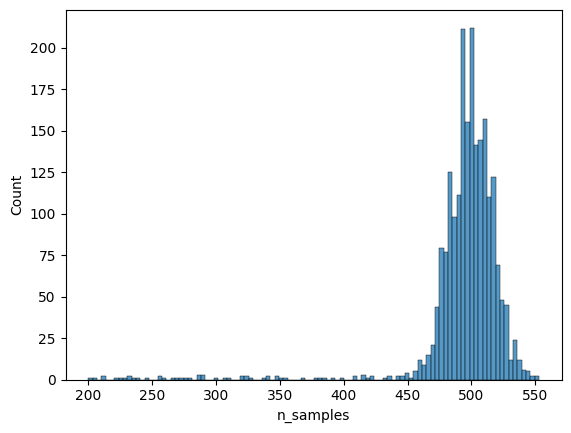

In [120]:
sns.histplot(df_windows['n_samples'])

Видно, что сэмплы распределены неравномерно по окнам. Экспериментально вручную подобрана граница min_samples=200. Удаление хвоста снижает метрику

In [121]:
df_windows["n_samples"].quantile(0.01)

np.float64(287.39)

Сборка колонок по смыслу - метаданные и полезные данные

In [122]:
meta_cols = [
    "subject_id",
    "window_start_time",
    "window_end_time",
    "window_center_time",
    "n_samples",
]

feature_cols = [
    col for col in df_windows.columns
    if col not in meta_cols
]

print(feature_cols)

['handMagne1_mean', 'handMagne1_std', 'handMagne1_min', 'handMagne1_max', 'handMagne1_median', 'handMagne1_q25', 'handMagne1_q75', 'handMagne1_energy', 'handMagne2_mean', 'handMagne2_std', 'handMagne2_min', 'handMagne2_max', 'handMagne2_median', 'handMagne2_q25', 'handMagne2_q75', 'handMagne2_energy', 'handMagne3_mean', 'handMagne3_std', 'handMagne3_min', 'handMagne3_max', 'handMagne3_median', 'handMagne3_q25', 'handMagne3_q75', 'handMagne3_energy', 'chestMagne1_mean', 'chestMagne1_std', 'chestMagne1_min', 'chestMagne1_max', 'chestMagne1_median', 'chestMagne1_q25', 'chestMagne1_q75', 'chestMagne1_energy', 'chestMagne2_mean', 'chestMagne2_std', 'chestMagne2_min', 'chestMagne2_max', 'chestMagne2_median', 'chestMagne2_q25', 'chestMagne2_q75', 'chestMagne2_energy', 'chestMagne3_mean', 'chestMagne3_std', 'chestMagne3_min', 'chestMagne3_max', 'chestMagne3_median', 'chestMagne3_q25', 'chestMagne3_q75', 'chestMagne3_energy', 'ankleMagne1_mean', 'ankleMagne1_std', 'ankleMagne1_min', 'ankleMagne

In [123]:
# Стандартизация по одному участнику
def normalize_one_subject(
    df_windows,
    subj_id,
    feature_cols,
):
    df_subject = df_windows[
        df_windows["subject_id"] == subj_id
    ].copy()

    scaler = StandardScaler()

    df_subject[feature_cols] = scaler.fit_transform(
        df_subject[feature_cols]
    )

    return df_subject

# Стандартизация по всем участникам
def normalize_all_subjects(
    df_windows,
    feature_cols,
):
    result = []

    subject_ids = sorted(
        df_windows["subject_id"].unique()
    )

    for subj_id in subject_ids:
        df_subject_norm = normalize_one_subject(
            df_windows=df_windows,
            subj_id=subj_id,
            feature_cols=feature_cols,
        )

        result.append(df_subject_norm)

    return pd.concat(
        result,
        axis=0
    ).reset_index(drop=True)

In [124]:
df_windows_norm = normalize_all_subjects(
    df_windows=df_windows,
    feature_cols=feature_cols,
)

PCA для снижения размерности и устранения возможной мультиколлинеарности

In [125]:
X = df_windows_norm[feature_cols].copy()

In [126]:
pca = PCA(
    n_components=0.99,
    random_state=42
)

X_pca = pca.fit_transform(X)

In [127]:
print(X.shape)
print(X_pca.shape)
print(pca.explained_variance_ratio_.sum())

(2140, 216)
(2140, 87)
0.9902137551171789


При объяснении более 99% дисперсии размерность понижается более чем в 2 раза - с 216 признаков до 87 главных компонент. Это упрощает работу кластеризаторов.

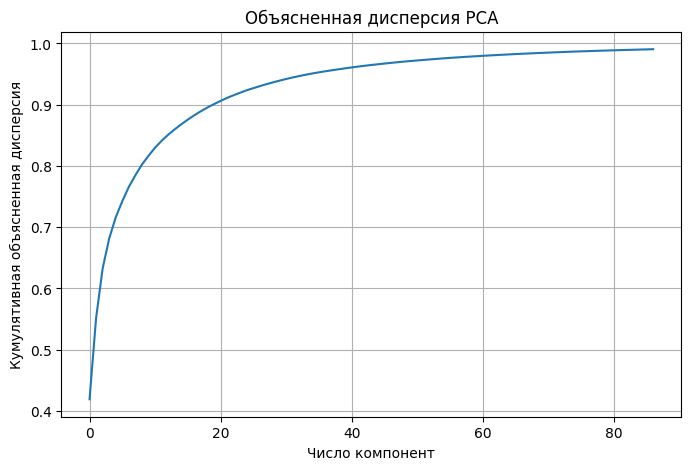

In [128]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    )
)

plt.xlabel("Число компонент")
plt.ylabel("Кумулятивная объясненная дисперсия")
plt.title("Объясненная дисперсия PCA")

plt.grid(True)
plt.show()

In [129]:
pca_cols = [
    f"PC{i+1}"
    for i in range(X_pca.shape[1])
]

df_pca = pd.DataFrame(
    X_pca,
    columns=pca_cols,
    index=df_windows_norm.index
)

df_pca = pd.concat(
    [
        df_windows_norm[meta_cols],
        df_pca
    ],
    axis=1
)

In [130]:
df_pca

,subject_id,window_start_time,window_end_time,window_center_time,n_samples,PC1,PC2,PC3,PC4,PC5,...,PC78,PC79,PC80,PC81,PC82,PC83,PC84,PC85,PC86,PC87
0,1,37.66,47.66,42.66,503,-0.014361,2.854194,3.309215,0.704541,2.736653,...,0.217186,-0.565080,0.187519,-0.435468,-0.377148,0.123101,-0.258066,0.034671,1.101690,0.159379
1,1,42.66,52.66,47.66,493,2.469034,-5.159214,3.315717,1.646749,3.311245,...,-0.042868,0.273778,-0.736260,0.087689,0.344142,-0.094011,-0.698697,-0.051017,-1.172351,0.294049
2,1,47.66,57.66,52.66,502,-5.677492,-9.179285,0.554592,0.541208,1.965523,...,-0.037757,-0.387921,-0.324880,0.693244,0.155549,-0.301830,0.258193,0.812784,-0.197631,0.438138
3,1,52.66,62.66,57.66,510,-12.284174,-8.326512,-2.546361,0.388970,0.444781,...,-0.104586,-0.619795,0.072653,0.266308,-0.275683,0.057487,0.217242,0.273478,-0.183444,0.111313
4,1,57.66,67.66,62.66,517,-12.947224,-8.320383,-2.740563,0.697084,0.122306,...,-0.060434,-0.351147,-0.056409,0.261446,0.058234,-0.105145,0.091073,0.044892,-0.069765,-0.145168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2135,8,3597.37,3607.37,3602.37,508,16.920812,-9.324862,-3.036117,-1.362652,2.747619,...,0.299254,0.343146,0.068200,0.031219,0.025403,-0.217343,0.060023,-0.458906,-0.179475,-0.273685
2136,8,3602.37,3612.37,3607.37,513,16.836590,-9.175239,-3.131708,-1.678975,2.718844,...,0.297935,0.403397,-0.238627,0.050920,0.151266,-0.111266,0.061749,-0.556800,-0.286778,-0.209669
2137,8,3607.37,3617.37,3612.37,519,17.088766,-9.367816,-3.431259,-1.593028,3.317630,...,0.359619,0.177015,-0.006056,0.195893,-0.066220,-0.154975,0.022218,-0.574267,0.139455,-0.058796
2138,8,3612.37,3622.37,3617.37,522,14.493361,-6.260305,-1.710051,1.025020,2.027241,...,0.090526,-0.422855,0.112627,-0.667337,-0.497208,-0.353716,0.185851,0.447169,0.083199,-0.374839


In [131]:
X_cluster = df_pca[pca_cols].copy()

Кластеризатор HDBSCAN наиболее устойчив к шуму и автоматически определяет количество кластеров. В задаче с шумными данными, как эта, он существенно превосходит KMeans. Вручную подобраны параметры:

In [132]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=70,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

cluster_labels = clusterer.fit_predict(X_cluster)
df_pca["cluster_id"] = cluster_labels
df_pca["cluster_id"].value_counts().sort_index()

,count
cluster_id,
-1,448
0,293
1,130
2,290
3,424
4,255
5,300


In [133]:
pd.crosstab(
    df_pca["cluster_id"],
    df_pca["subject_id"]
)

subject_id,1,2,3,4,5,6,7,8
cluster_id,,,,,,,,
-1,66,45,55,45,68,24,22,123
0,40,42,38,41,42,43,47,0
1,39,8,0,0,43,40,0,0
2,44,45,0,32,44,39,42,44
3,40,58,44,53,59,50,63,57
4,0,31,34,46,39,41,21,43
5,50,49,29,40,14,41,53,24


Классы хорошо распределены по участникам. Значит модель классифицирует скорее активности, а не участников.

In [134]:
df_pca.groupby("cluster_id")[
    ["n_samples"]
].describe()

n_samples                                                       \
               count        mean        std    min     25%    50%     75%   
cluster_id                                                                  
-1             448.0  480.997768  58.564044  200.0  483.00  496.0  508.00   
 0             293.0  502.006826  15.327697  461.0  492.00  502.0  513.00   
 1             130.0  497.223077  16.005941  461.0  487.25  496.0  507.75   
 2             290.0  498.551724  18.304019  368.0  488.00  499.0  511.00   
 3             424.0  499.808962  15.323272  449.0  489.00  500.0  510.00   
 4             255.0  498.878431  17.404320  437.0  486.00  500.0  510.00   
 5             300.0  494.073333  47.131510  212.0  491.75  501.0  513.00   

                   
              max  
cluster_id         
-1          553.0  
 0          538.0  
 1          545.0  
 2          540.0  
 3          546.0  
 4          543.0  
 5          549.0

In [135]:
# Присвоение оконных кластеров обратно строкам на основании оси времени по ближайшему времени к центру окна
def assign_window_clusters_to_rows(
    df_rows,
    df_windows_clustered
):
    result = []

    for subj_id, df_subject in df_rows.groupby("subject_id"):
        df_subject = df_subject.copy()

        windows_subj = df_windows_clustered[
            df_windows_clustered["subject_id"] == subj_id
        ].copy()

        centers = windows_subj["window_center_time"].values
        clusters = windows_subj["cluster_id"].values

        timestamps = df_subject["timestamp"].values

        nearest_idx = np.abs(
            timestamps[:, None] - centers[None, :] # broadcast, одномерные массивы раскрываются и выполняется вычитание матриц
        ).argmin(axis=1)

        df_subject["cluster_id"] = clusters[nearest_idx]

        result.append(df_subject)

    return pd.concat(result, axis=0).sort_values("row_id").reset_index(drop=True)

In [136]:
df_final = assign_window_clusters_to_rows(
    df_rows=df_prep,
    df_windows_clustered=df_pca
)

In [137]:
df_final[["row_id", "subject_id", "timestamp", "cluster_id"]].head(30)

,row_id,subject_id,timestamp,cluster_id
0,0,5,252.75,0
1,1,2,3652.45,2
2,2,8,504.76,4
3,3,2,2801.61,3
4,4,6,441.01,4
5,5,6,2407.75,3
6,6,2,288.18,-1
7,7,1,2926.96,2
8,8,8,738.33,5
9,9,1,2934.54,2


In [138]:
# Перенумерация кластеров согласно требованиям Kaggle
def renumber_by_appearance(df):
    cluster_map = {}
    next_cluster_id = 1

    new_clusters = []

    for cluster in df["cluster_id"]:
        if cluster not in cluster_map:
            cluster_map[cluster] = next_cluster_id
            next_cluster_id += 1

        new_clusters.append(cluster_map[cluster])

    df["activityID"] = new_clusters

    return df

In [139]:
df_final = renumber_by_appearance(df_final)
df_final[["subject_id", "timestamp", "cluster_id", "activityID"]].head(30)

,subject_id,timestamp,cluster_id,activityID
0,5,252.75,0,1
1,2,3652.45,2,2
2,8,504.76,4,3
3,2,2801.61,3,4
4,6,441.01,4,3
5,6,2407.75,3,4
6,2,288.18,-1,5
7,1,2926.96,2,2
8,8,738.33,5,6
9,1,2934.54,2,2


In [140]:
df_final[["activityID"]].to_csv("clusters_result.csv", index=True, index_label="Index")

csv_file = "clusters_result.csv"
zip_file = "clusters_result.zip"

with zipfile.ZipFile(zip_file, "w", zipfile.ZIP_DEFLATED) as z:
    z.write(csv_file)

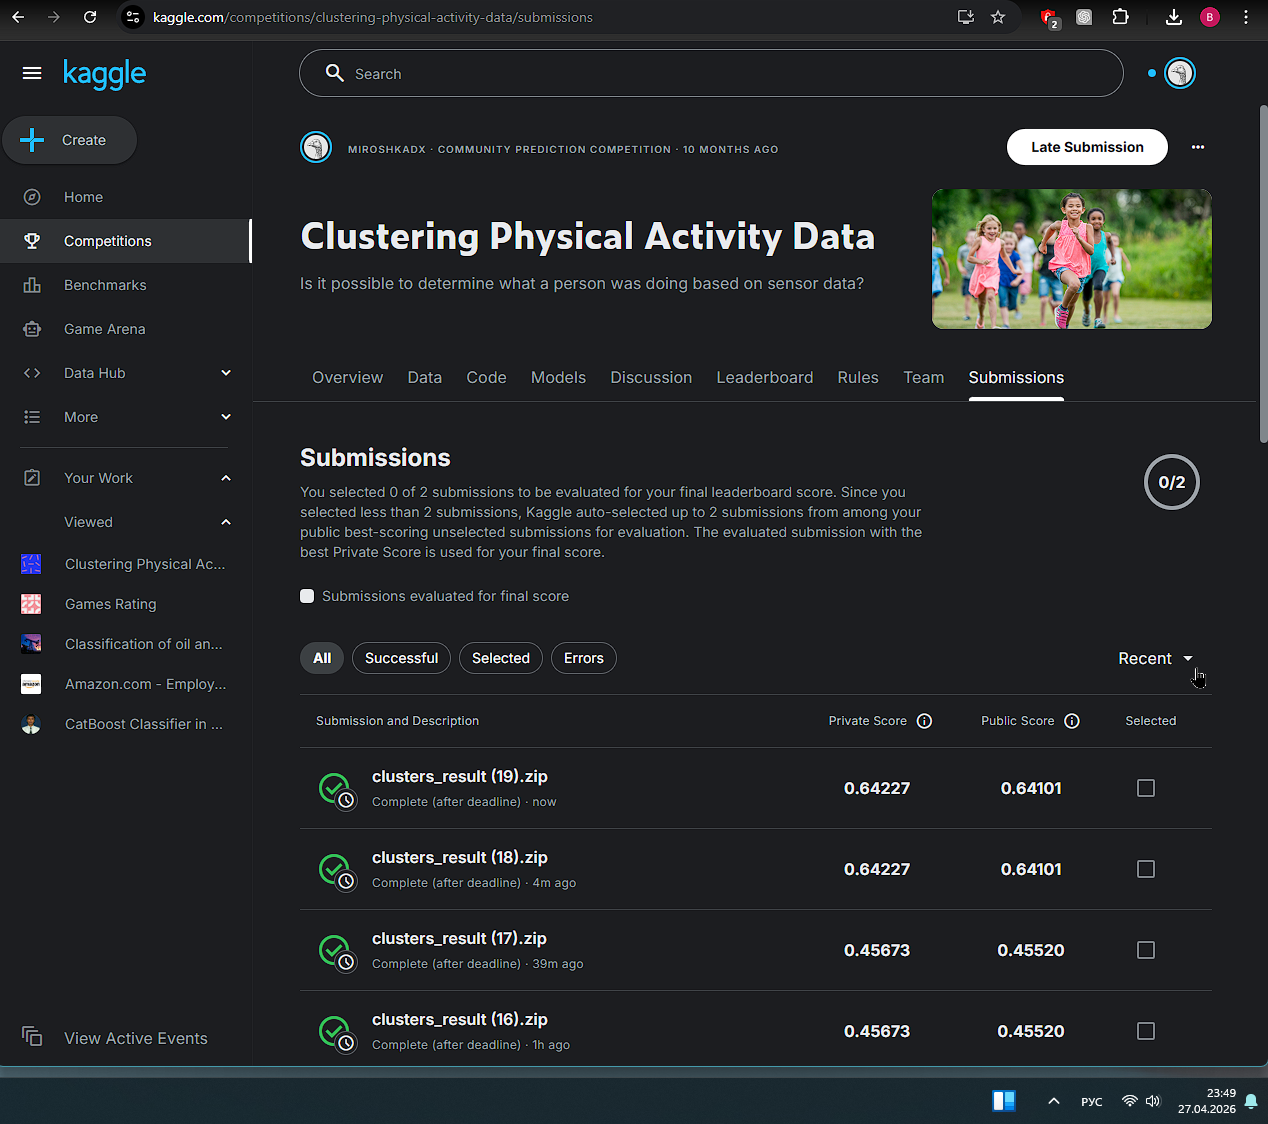